In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/imdb_cleaned.csv')
df.head()

,rank,year,duration,age_limit,rating,numberof_ratings,Metascore,description,name
0,1,1994,142,15,9.3,2.9,82.0,"Over the course of several years, two convicts...",The Shawshank Redemption
1,2,1972,175,15,9.2,2.0,100.0,The aging patriarch of an organized crime dyna...,The Godfather
2,3,2008,152,12A,9.0,2.9,84.0,When the menace known as the Joker wreaks havo...,The Dark Knight
3,4,2003,201,12A,9.0,2.0,94.0,Gandalf and Aragorn lead the World of Men agai...,The Lord of the Rings: The Return of the King
4,5,1993,195,15,9.0,1.5,95.0,"In German-occupied Poland during World War II,...",Schindler's List


In [3]:
df.describe()

,rank,year,duration,rating,numberof_ratings,Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1991.842000,124.646000,7.972800,229.654900,79.596000
std,288.819436,24.411861,29.288915,0.273633,247.669618,11.005813
min,1.000000,1920.000000,0.000000,7.600000,1.000000,28.000000
25%,250.750000,1975.000000,103.750000,7.800000,51.000000,73.750000
50%,500.500000,1999.000000,121.000000,7.900000,118.500000,81.000000
75%,750.250000,2012.000000,140.000000,8.100000,332.000000,87.000000
max,1000.000000,2024.000000,321.000000,9.300000,999.000000,100.000000


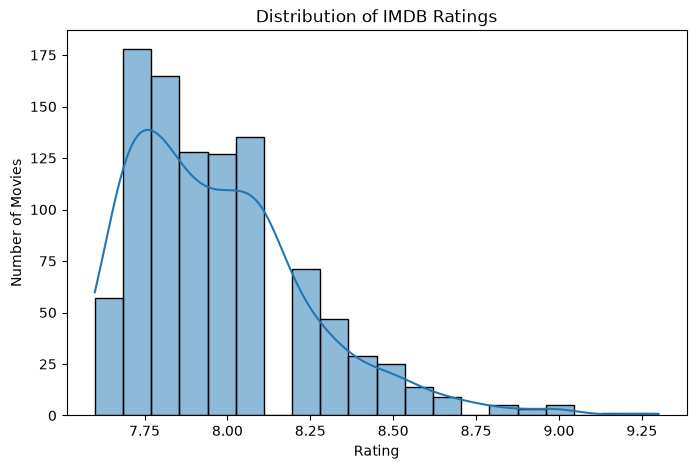

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20, kde=True)
plt.title('Distribution of IMDB Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Movies')
plt.show()

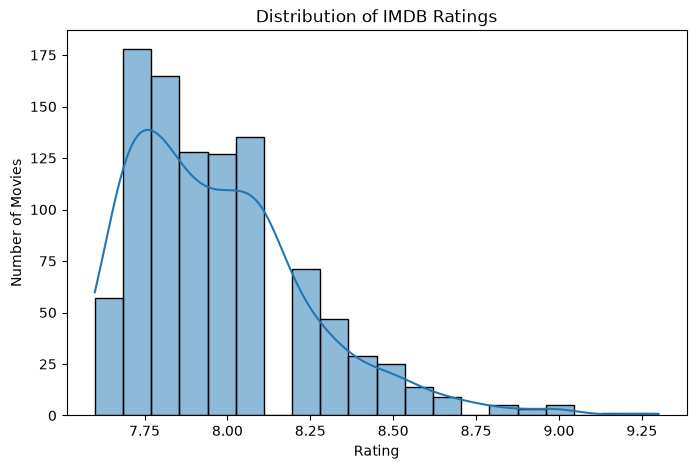

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20, kde=True)
plt.title('Distribution of IMDB Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Movies')
plt.savefig('../visuals/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
top_10 = df.sort_values('rating', ascending=False).head(10)
top_10[['name', 'year', 'rating', 'Metascore']]

,name,year,rating,Metascore
0,The Shawshank Redemption,1994,9.3,82.0
1,The Godfather,1972,9.2,100.0
2,The Dark Knight,2008,9.0,84.0
3,The Lord of the Rings: The Return of the King,2003,9.0,94.0
4,Schindler's List,1993,9.0,95.0
5,12 Angry Men,1957,9.0,97.0
6,The Godfather Part II,1974,9.0,90.0
7,The Lord of the Rings: The Fellowship of the ...,2001,8.9,92.0
8,Pulp Fiction,1994,8.9,95.0
9,12th Fail,2023,8.9,81.0


In [7]:
correlation = df['rating'].corr(df['Metascore'])
print(f"Correlation between Rating and Metascore: {correlation:.2f}")

Correlation between Rating and Metascore: 0.23


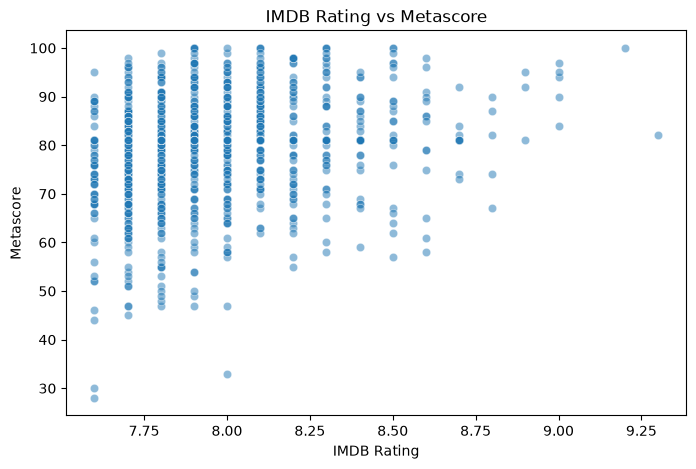

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='rating', y='Metascore', alpha=0.5)
plt.title('IMDB Rating vs Metascore')
plt.xlabel('IMDB Rating')
plt.ylabel('Metascore')
plt.savefig('../visuals/rating_vs_metascore.png', dpi=150, bbox_inches='tight')
plt.show()

## IMDB Rating vs Metascore
While there is a slight positive relationship between IMDB user ratings 
and critic Metascores, the correlation is weak. Movies with the same 
IMDB rating can have Metascores ranging from the 30s to 100, showing 
that audience and critic opinions often diverge significantly.

In [9]:
df['decade'] = (df['year'] // 10) * 10

decade_avg = df.groupby('decade')['rating'].mean().reset_index()
decade_avg

,decade,rating
0,1920,8.090909
1,1930,7.966667
2,1940,7.985714
3,1950,8.067241
4,1960,7.979730
5,1970,7.997015
6,1980,7.963636
7,1990,7.988321
8,2000,7.930047
9,2010,7.950218


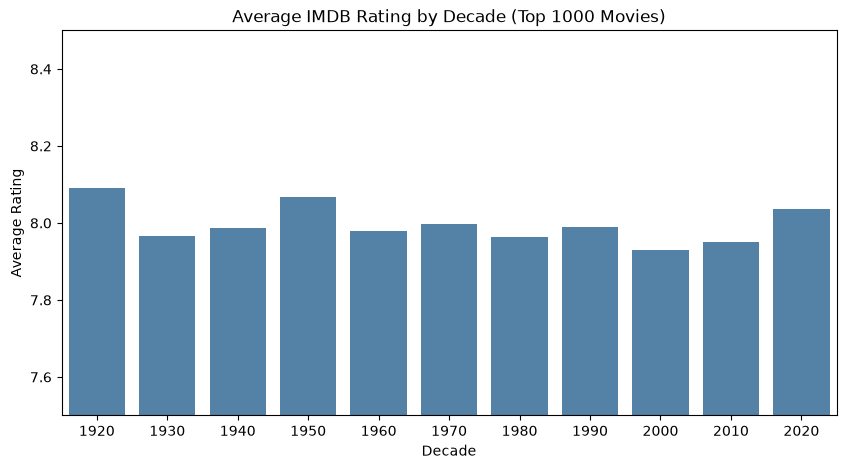

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(data=decade_avg, x='decade', y='rating', color='steelblue')
plt.title('Average IMDB Rating by Decade (Top 1000 Movies)')
plt.xlabel('Decade')
plt.ylabel('Average Rating')
plt.ylim(7.5, 8.5)  # zoom in since differences are small
plt.savefig('../visuals/rating_by_decade.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
decade_counts = df['decade'].value_counts().sort_index()
decade_counts

decade
1920     11
1930     24
1940     42
1950     58
1960     74
1970     67
1980     88
1990    137
2000    213
2010    229
2020     57
Name: count, dtype: int64

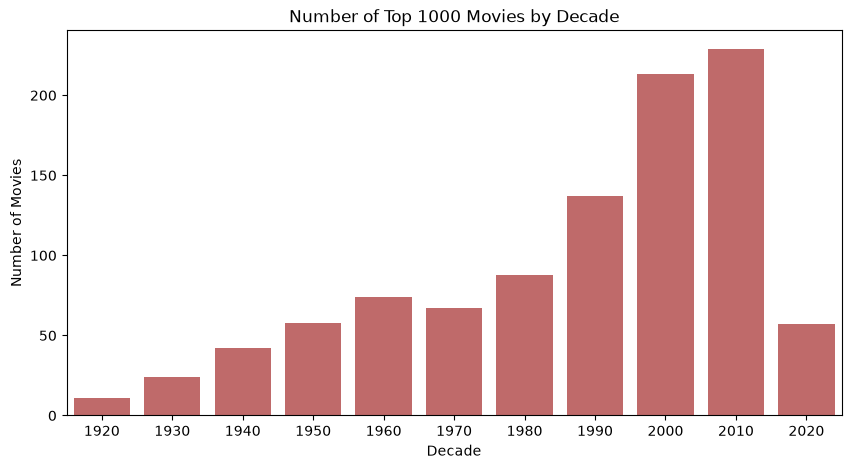

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(x=decade_counts.index, y=decade_counts.values, color='indianred')
plt.title('Number of Top 1000 Movies by Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.savefig('../visuals/movie_count_by_decade.png', dpi=150, bbox_inches='tight')
plt.show()